# CESM2 Large Ensemble: Global Mean Surface Temperature

```{image} ../../thumbnails/gdex_logo.png
:alt: GDEX Cookbook logo
:width: 200px
```

---

## Overview

GDEX hosts output from a range of General Circulation Models (GCMs), including
CMIP-era simulations. This notebook demonstrates how to access and analyze that
output directly from GDEX, using one such dataset as a worked example.

The [CESM2 Large Ensemble](https://www.cesm.ucar.edu/community-projects/lens2)
(CESM2-LE) is a 100-member ensemble of climate simulations run with the Community
Earth System Model v2, designed to separate forced climate change from internal
variability. GDEX hosts it as dataset [`d010092`](https://gdex.ucar.edu/datasets/d010092/)
in cloud-optimized **Zarr** stores served over **OSDF**.

In this notebook we compute the ensemble's **Global Mean Surface Temperature
(GMST)** — opening the Zarr stores directly (no intake-ESM) and using a Dask
`LocalCluster` to handle the out-of-core computation.

1. Spin up a Dask `LocalCluster`
2. Open CESM2-LE `TREFHT` Zarr stores directly over OSDF
3. Compute an area-weighted, annual-mean GMST across the ensemble
4. Visualize the GMST anomaly and its ensemble spread

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Introduction to ARCO/Zarr on GDEX](../services/zarr_intro.ipynb) | Necessary | Opening Zarr stores on GDEX |
| [xarray](https://docs.xarray.dev) | Necessary | Labeled N-D arrays |
| [Dask](https://docs.dask.org) | Necessary | Parallel / out-of-core compute |
| [OSDF Cookbook](https://projectpythia.org/osdf-cookbook/) | Helpful | What OSDF is and how to stream data |
| Area-weighted averaging | Helpful | Why we cosine-weight by latitude |

- **Time to learn**: 35 minutes

---

## Imports

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from dask.distributed import LocalCluster

## Spin up a Dask cluster

CESM2-LE `TREFHT` is far larger than memory (tens of GB per scenario across all
members). A Dask [`LocalCluster`](https://docs.dask.org/en/stable/deploying-python.html)
parallelizes the computation across your machine's cores and streams data lazily,
so we never hold the full arrays in memory at once. Click the dashboard link in
the output to watch tasks execute.

In [2]:
cluster = LocalCluster(
    n_workers=5,
    memory_limit="4GiB",)  # per worker
#
client = cluster.get_client()
client

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42809 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42809/status,
Dashboard: http://127.0.0.1:42809/status,Workers: 5
Total threads: 20,Total memory: 20.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42917,Workers: 0
Dashboard: http://127.0.0.1:42809/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44043,Total threads: 4
Dashboard: http://127.0.0.1:36013/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:44373,


## CESM2-LE on GDEX

We use **`TREFHT`** (reference-height air temperature, in K) at monthly frequency.
The ensemble is split across two forcing variants — `cmip6` and `smbb` (50 members
each, 100 total) — and two experiments: `historical` (1850–2014) and `ssp370`
(2015–2100). Each combination is a single Zarr store.

The store paths follow a regular naming pattern, so we build the URLs directly. You can also discover them on the
[`d010092` data-access page](https://gdex.ucar.edu/datasets/d010092/dataaccess/),
or from the dataset's intake-ESM catalog.)

:::{note}
GDEX serves these stores over the **Open Science Data Federation (OSDF)**. New to OSDF? See the [OSDF Cookbook](https://projectpythia.org/osdf-cookbook/).
:::

In [3]:
DSID = "d010092"
# base = f"https://osdf-director.osg-htc.org/ncar-gdex/{DSID}/atm/monthly"
base = f"osdf:///ncar-gdex/{DSID}/atm/monthly"
stores = {
    ("historical", "cmip6"): f"{base}/cesm2LE-historical-cmip6-TREFHT.zarr",
    ("ssp370", "cmip6"): f"{base}/cesm2LE-ssp370-cmip6-TREFHT.zarr",
    ("historical", "smbb"): f"{base}/cesm2LE-historical-smbb-TREFHT.zarr",
    ("ssp370", "smbb"): f"{base}/cesm2LE-ssp370-smbb-TREFHT.zarr",
}
stores

{('historical',
  'cmip6'): 'osdf:///ncar-gdex/d010092/atm/monthly/cesm2LE-historical-cmip6-TREFHT.zarr',
 ('ssp370',
  'cmip6'): 'osdf:///ncar-gdex/d010092/atm/monthly/cesm2LE-ssp370-cmip6-TREFHT.zarr',
 ('historical',
  'smbb'): 'osdf:///ncar-gdex/d010092/atm/monthly/cesm2LE-historical-smbb-TREFHT.zarr',
 ('ssp370',
  'smbb'): 'osdf:///ncar-gdex/d010092/atm/monthly/cesm2LE-ssp370-smbb-TREFHT.zarr'}

## Opening the Zarr stores

These are Zarr v2 stores with consolidated metadata, so we pass
`consolidated=True` and `zarr_format=2`. `chunks={}` keeps the arrays lazy
(Dask-backed) — nothing is read until we compute. We focus on the `cmip6` forcing
variant here; swap in `smbb` to analyze the other half of the ensemble.

In [4]:
def open_store(experiment, forcing):
    return xr.open_dataset(
        stores[(experiment, forcing)],
        engine="zarr",
        chunks={},
        consolidated=True,
        zarr_format=2,)

historical = open_store("historical", "cmip6")
ssp370 = open_store("ssp370", "cmip6")
historical

<xarray.Dataset> Size: 22GB
Dimensions:    (member_id: 50, time: 1980, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    time_bnds  (time, nbnd) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Dimensions without coordinates: nbnd
Data variables:
    TREFHT     (member_id, time, lat, lon) float32 22GB dask.array<chunksize=(1, 600, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    NCO:               netCDF Operators version 4.9.4 (Homepage = http://nco....
    logname:           sunseon
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    source:            CAM
    time_period_freq:  month_1
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...

## Computing area-weighted GMST

A simple average over grid cells would over-weight the poles, where cells cover
less area. Therefore the correct method is to weight each cell by the cosine of its latitude.
We average over latitude and longitude while **keeping `time` and `member_id`**,
so we retain one GMST time series per ensemble member.

In [5]:
def get_lat_name(ds):
    for lat_name in ["lat", "latitude"]:
        if lat_name in ds.coords:
            return lat_name
    raise RuntimeError("Couldn't find a latitude coordinate")


def global_mean(ds):
    lat = ds[get_lat_name(ds)]
    weight = np.cos(np.deg2rad(lat))
    weight /= weight.mean()
    other_dims = set(ds.dims) - {"time", "member_id"}
    return (ds * weight).mean(other_dims)

We concatenate `historical` and `ssp370` into one 1850–2100 timeline, take the
**annual mean**, compute the area-weighted global mean, and express it as an
anomaly relative to the 1850–1900 pre-industrial baseline.

:::{tip}
The `cmip6` variant has 50 members. To run faster on a laptop, subset members
before computing, e.g. `merged = merged.isel(member_id=slice(0, 10))`.
:::

In [6]:
%%time
merged = xr.concat([historical, ssp370], dim="time")
merged = merged.isel(member_id=slice(0, 10))

annual = merged["TREFHT"].resample(time="YS").mean()
gmst = global_mean(annual).rename("gmst")
gmst_ano = gmst - gmst.sel(time=slice("1850", "1900")).mean("time")

CPU times: user 461 ms, sys: 0 ns, total: 461 ms
Wall time: 456 ms


In [7]:
%%time
gmst_ano = gmst_ano.compute()

CPU times: user 9.68 s, sys: 705 ms, total: 10.4 s
Wall time: 18.2 s


## Visualizing the GMST anomaly

Plotting every member (thin grey lines) alongside the ensemble mean (bold) shows
both the forced warming signal and the spread from internal variability.

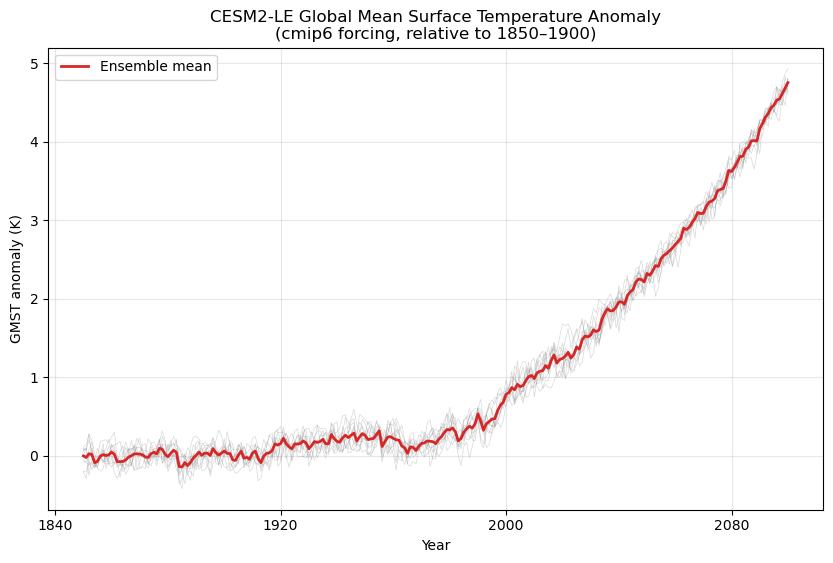

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

gmst_ano.plot.line(
    x="time", hue="member_id", add_legend=False,
    color="grey", lw=0.5, alpha=0.3, ax=ax,
)
gmst_ano.mean("member_id").plot.line(
    x="time", color="C3", lw=2, ax=ax, label="Ensemble mean",)

ax.set_title("CESM2-LE Global Mean Surface Temperature Anomaly\n(cmip6 forcing, relative to 1850–1900)")
ax.set_ylabel("GMST anomaly (K)")
ax.set_xlabel("Year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [9]:
client.close()
cluster.close()

---

## Summary

We computed the CESM2 Large Ensemble's global mean surface temperature from
GDEX's Zarr stores: spin up a `LocalCluster` → open the stores lazily →
area-weight and average to annual GMST per member → plot the forced signal
against the ensemble spread.

### What's next?

Continue to the [High-Resolution Dataset Workflow](hi-res.ipynb), which applies a
similar GDEX access pattern to high-resolution model output.

## Resources and references

- [CESM2 Large Ensemble project](https://www.cesm.ucar.edu/community-projects/lens2)
- [GDEX CESM2-LE dataset (`d010092`)](https://gdex.ucar.edu/datasets/d010092/)
- [Original GDEX CESM GMST example](https://ncar.github.io/gdex-examples/cesm-gmst-ncar/)
- [OSDF Cookbook (Project Pythia)](https://projectpythia.org/osdf-cookbook/)
- [xarray documentation](https://docs.xarray.dev)
- [Dask distributed](https://distributed.dask.org)